In [31]:
import torch
import json
from torch_geometric.nn import SAGEConv  
from torch_geometric.data import Data
from torch_geometric.utils import negative_sampling
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np
from minisom import MiniSom
import plotly.express as px
import pandas as pd

In [32]:
def json_to_pyg_data(json_data):
    items = json_data["network"]["items"]
    links = json_data["network"]["links"]

    id_map = {node["id"]: i for i, node in enumerate(items)}

    node_features = []
    for node in items:
        features = [
            node["weights"].get("WoS Categories", 0),
            node["weights"].get("Document Types",  0),
            node["weights"].get("Documents",0),
            node["scores"].get("Ave. citations",0.0),
            node["scores"].get("Ave. authorships",0.0),
            node["scores"].get("Ave. references",0.0),
            node["scores"].get("Percent of documents",0.0),
            node["scores"].get("Percent of documents Int. Coll.",0.0)
        ]
        node_features.append(features)
    
    #x = torch.tensor(node_features, dtype=torch.float)
    features_array = np.array(node_features, dtype=float)

    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features_array)
    x = torch.tensor(features_scaled, dtype=torch.float)

    #Aristas
    sources = []
    targets = []
    edge_weights = []
    
    for link in links:
        u_str = link["source_id"]
        v_str = link["target_id"]
        strength = link["strength"]

        u = id_map[u_str]
        v = id_map[v_str]

        sources.append(u)
        targets.append(v)
        edge_weights.append(strength)


    edge_index = torch.tensor([sources, targets], dtype = torch.long)
    edge_attr = torch.tensor(edge_weights, dtype=torch.float).view(-1,1) #al ser de una sola dimensión, lo pasamos a una matriz de x filas por 1 columna


    #El tipo "Data" es exclusivamente para que sage pueda procesar el grafo
    data = Data(x=x, edge_index = edge_index, edge_attr = edge_attr)
    #x son mis caracteristicas
    #edge_index es la topologia (aristas)
    #edge_attr en este caso son únicamente los pesos

    return data

In [33]:
with open("./network_2003.json", "r") as f:
    raw_json = json.load(f)

snapshot_2003 = json_to_pyg_data(raw_json)
print(f"Snapshot creado: {snapshot_2003}")
print(f"Nodos: {snapshot_2003.num_nodes}, Features: {snapshot_2003.num_node_features}")

Snapshot creado: Data(x=[152, 8], edge_index=[2, 151], edge_attr=[151, 1])
Nodos: 152, Features: 8


In [34]:
data = snapshot_2003
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)
data = data.to(device)

Usando dispositivo: cpu


In [35]:
class GraphSAGEEncoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)
        self.relu = torch.nn.ReLU()
        self.dropout = torch.nn.Dropout(p=0.5)

    def forward(self, x, edge_index):

        x = self.conv1(x, edge_index)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x  # embeddings finales

In [36]:
in_channels = data.num_node_features   # En nuestro caso son 8 features
hidden_channels = 32
out_channels = 16   # dimensión del embedding final

model = GraphSAGEEncoder(in_channels, hidden_channels, out_channels).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.BCEWithLogitsLoss()

In [37]:

def get_link_logits(z, edge_index):
    # z: [N, d]
    src, dst = edge_index
    # producto punto entre embeddings de los extremos
    # Si dos vectores apuntan a la misma direccion (son similares) entonces tendrán un valor positivo, en caso contrario
    return (z[src] * z[dst]).sum(dim=-1)  # [num_edges]

def train_linkpred(model, data, epochs=200):
    model.train()
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()
        z = model(data.x, data.edge_index)
        # aristas  positivas (reales)
        pos_edge_index = data.edge_index
        # aristas negativas
        neg_edge_index = negative_sampling(
            edge_index=pos_edge_index,
            num_nodes=data.num_nodes,
            num_neg_samples=pos_edge_index.size(1),  # mismo número que positivas
            method="sparse"
        )
        # 4) Logits para positivas y negativas
        pos_logits = get_link_logits(z, pos_edge_index)
        neg_logits = get_link_logits(z, neg_edge_index)
        logits = torch.cat([pos_logits, neg_logits], dim=0)
        labels = torch.cat([
            torch.ones(pos_logits.size(0), device=device),
            torch.zeros(neg_logits.size(0), device=device)
        ], dim=0)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        if epoch % 20 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f}")
    return model

In [38]:
trained_model = train_linkpred(model, data, epochs=200)
trained_model.eval()
with torch.no_grad():
    z = trained_model(data.x, data.edge_index)  # [num_nodes, out_channels]

embeddings = z.cpu().numpy()
print("dimension de embeddings:", embeddings.shape)  # (num_nodes, out_channels)
print(embeddings[0])

items = raw_json["network"]["items"]
clusters = [node.get("cluster", -1) for node in items]  # lista de clusters


Epoch 001 | Loss: 0.5782
Epoch 020 | Loss: 0.4402
Epoch 040 | Loss: 0.4214
Epoch 060 | Loss: 0.4141
Epoch 080 | Loss: 0.3972
Epoch 100 | Loss: 0.4181
Epoch 120 | Loss: 0.3821
Epoch 140 | Loss: 0.4024
Epoch 160 | Loss: 0.3810
Epoch 180 | Loss: 0.3863
Epoch 200 | Loss: 0.3602
dimension de embeddings: (152, 16)
[ 10.988257    -3.1885679    1.6809512   11.269717    -3.689194
   1.6363544   -4.547018   -12.794076    11.890419    11.7563
   3.5394094   -8.874979    13.14563     -2.074023    -0.15551141
  -0.09508725]


Entrenando SOM...
SOM entrenado.


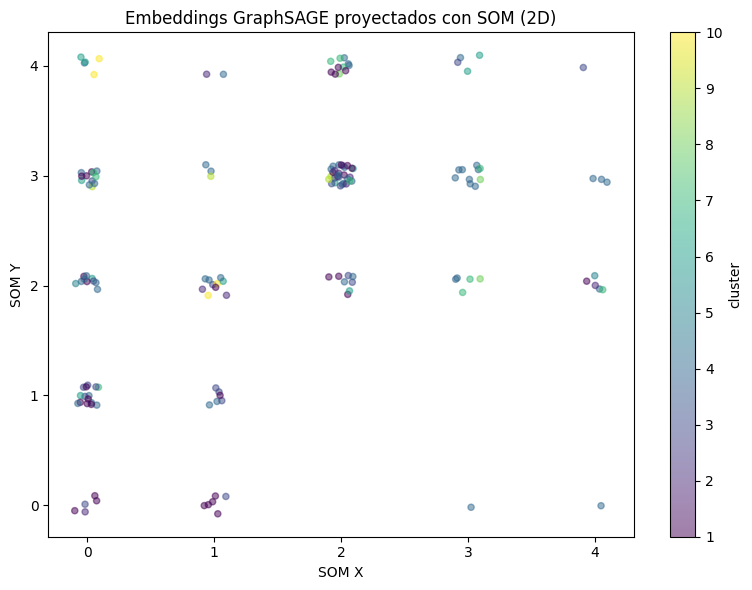

In [39]:

num_nodes, d = embeddings.shape # embeddings := (num_nodes, d)

# Mapa SOM de 10x10
som_x, som_y = 5, 5

som = MiniSom(
    x=som_x,
    y=som_y,
    input_len=d,
    sigma=1.0,
    learning_rate=0.5,
    neighborhood_function='gaussian',
    random_seed=42
)

# Inicializar pesos 
som.random_weights_init(embeddings)
print("Entrenando SOM...")
som.train_random(embeddings, num_iteration=1000)
print("SOM entrenado.")

# Proyectar cada embedding al nodo ganador del SOM
items = raw_json["network"]["items"]
clusters = [node.get("cluster", -1) for node in items]

som_coords_x = []
som_coords_y = []

for v in embeddings:
    i, j = som.winner(v)  # coordenadas (fila, columna) en la rejilla
    som_coords_x.append(i)
    som_coords_y.append(j)

som_coords_x = np.array(som_coords_x, dtype=float)
som_coords_y = np.array(som_coords_y, dtype=float)


jitter = 0.1 # "jitter" para que los puntos no se sobrepongan exactamente
som_coords_x = som_coords_x + np.random.uniform(-jitter, jitter, size=num_nodes)
som_coords_y = som_coords_y + np.random.uniform(-jitter, jitter, size=num_nodes)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(som_coords_x, som_coords_y, c=clusters, s=20, alpha=0.5)
plt.title("Embeddings GraphSAGE proyectados con SOM (2D)")
plt.xlabel("SOM X")
plt.ylabel("SOM Y")
plt.colorbar(scatter, label="cluster")
#plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()





In [ ]:


# DataFrame con todo los datos
df_vis = pd.DataFrame({
    'x': som_coords_x,
    'y': som_coords_y,
    'label': [node["label"] for node in items],  # Nombres para el mouse
    'cluster': [str(c) for c in clusters],       # Convertir a string 
    'docs': [node["weights"]["Documents"] for node in items] # Tamaño por documentos 
})

# gráfica interactiva
fig = px.scatter(
    df_vis, 
    x='x', 
    y='y', 
    color='cluster',
    hover_name='label',
    size='docs',
    title="Mapa Interactivo de Micro-Tópicos",
    template="plotly_white"
)

fig.show()